# Thameswood Distillers — Iowa target accounts

**V1 baseline.** The 25 Iowa liquor stores Thameswood should approach next, ranked by how much
**premium (imported) gin** they bought over 2025–2026, with the reasoning behind the order.

---

### The headline

- **1,143** Iowa stores are eligible: they bought imported gin in the window and are not already
  won or lost in the CRM.
- The market is **extremely concentrated** — the top 25 stores account for **45%** of every
  premium-gin dollar in that universe, and the top 100 for **73%**.
- **None of the top 25 are in Thameswood's CRM.** All 25 are net-new. The closest existing
  prospect ranks #28.
- **19 of the top 25 are chain locations** (Hy-Vee, Costco, Sam's Club). So the list is 25 stores
  but only **9 buying decisions** — read section 4 before acting on it.

### How to read this

Section 1 is the deliverable. Sections 2–6 are the argument for it. Section 7 is what we assumed
and where V1 is weak; section 8 is what V2 fixes.

### Where the numbers come from

Every figure below is computed in **dbt** and read out of one table,
`analytics.mart_target_accounts`. This notebook contains **no ranking logic** — it queries,
formats and plots. That is deliberate: two places that compute the same number eventually
disagree, and the warehouse is the one that is version-controlled and tested (65 tests pass on
the current build).

The one exception is the chain grouping in section 4, which is exploratory and clearly marked as
such. It does not feed the ranking. If it survives review it moves into dbt as a proper model.

```
raw_crm.*  ─┐
            ├─ stg_* (clean/type) ─ int_* (current state, pivot) ─ mart_target_accounts
raw_iowa.*  ┘
```

In [1]:
import os
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from google.cloud import bigquery

PROJECT = os.environ.get("BQ_PROJECT_ID", "gin-accounts-recommendation")
client = bigquery.Client(project=PROJECT, location="US")

# Palette and chart chrome. Single source so every figure below matches.
# Validated for colour-vision deficiency: blue vs orange, worst-case dE 24.7.
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#d5d4cd"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "figure.dpi": 130,
})

targets = client.query(f'''
    select * from `{PROJECT}.analytics.mart_target_accounts` order by target_rank
''').to_dataframe()

usd = lambda v: f"${v:,.0f}"
print(f"{len(targets):,} eligible stores loaded from {PROJECT}.analytics.mart_target_accounts")

/Users/jeanchacon/Documents/codes/interviews/alchemia-labs-tech-assessment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


1,143 eligible stores loaded from gin-accounts-recommendation.analytics.mart_target_accounts


## 1. The list

The 25 stores to approach next. `premium_gin` is imported-gin purchases over Jan 2025 – Apr 2026;
`prem %` is what share of that store's *total* gin spend is premium — a store at 86% sells
almost exclusively at Thameswood's price point.

In [2]:
top = targets[targets["is_top_target"]].copy()

view = pd.DataFrame({
    "#": top["target_rank"],
    "Store": top["store_name"].str.title(),
    "City": top["city"].str.title(),
    "County": top["county"].str.title(),
    "Premium gin": top["premium_gin_dollars"].map(usd),
    "prem %": (top["premium_share_of_gin"] * 100).round(0).astype(int).astype(str) + "%",
    "Orders": top["premium_gin_order_lines"],
    "In CRM?": top["target_type"].map({"net_new": "no — needs sourcing",
                                       "known_prospect": "yes — open prospect"}),
}).set_index("#")

display(view)

,Store,City,County,Premium gin,prem %,Orders,In CRM?
#,,,,,,,
1,Central City 2,Des Moines,Polk,"$415,501",57%,705,no — needs sourcing
2,Hy-Vee #3 / Bdi / Des Moines,Des Moines,Polk,"$377,186",57%,620,no — needs sourcing
3,Hy-Vee Wine And Spirits #1 (1281) / Iowa City,Iowa City,Johnson,"$225,186",60%,282,no — needs sourcing
4,Benz Distributing,Cedar Rapids,Linn,"$145,911",63%,634,no — needs sourcing
5,Another Round / Dewitt,Dewitt,Clinton,"$131,886",64%,398,no — needs sourcing
6,Wall To Wall Wine And Spirits / West Des Moines,West Des Moines,Dallas,"$126,828",59%,281,no — needs sourcing
7,Costco Wholesale #788 / Wdm,West Des Moines,Dallas,"$106,328",46%,16,no — needs sourcing
8,Sam'S Club 8162 / Cedar Rapids,Cedar Rapids,Linn,"$83,107",86%,102,no — needs sourcing
9,Hy-Vee Food Store / Coralville,Coralville,Johnson,"$79,753",67%,254,no — needs sourcing


**Why this order.** `cat_group` decides which dollars *count*; `net_sale_dollars` decides the
*order*. Ranking on a store's total liquor sales would just return the 25 biggest shops in Iowa —
something the client already knows, for free. Ranking on **imported gin specifically** says these
stores' customers have already proven they will pay premium prices for exactly this product.

V1 uses that one measure and no weights. There is no composite score to argue about, and every
later refinement is purely additive.

## 2. Why these 25 — the market is a long tail

The cut at 25 is not arbitrary. Premium gin spending in Iowa is dominated by a very small number
of stores: mean spend is **$5,106** but the median is **$783** — a 6.5× gap that says most of the
1,143 eligible stores buy a token amount.

Note the log scale on the vertical axis: each gridline is 10× the one below it. The top 25 (blue)
sit one to three orders of magnitude above the tail.

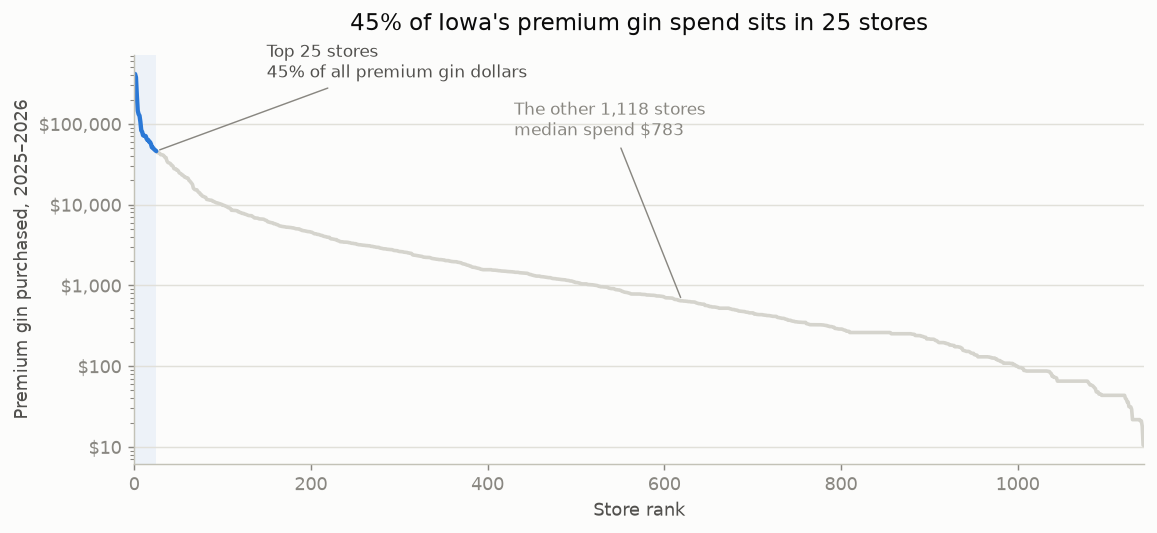

top 25  -> 45% of premium gin dollars
top 100 -> 73%
mean $5,106   median $783


In [3]:
d = targets.sort_values("target_rank")
x, y = d["target_rank"].to_numpy(), d["premium_gin_dollars"].to_numpy()

share_25 = y[:25].sum() / y.sum() * 100
share_100 = y[:100].sum() / y.sum() * 100
tail_i = min(620, len(y) - 1)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axvspan(0, 25, color=BLUE, alpha=0.07, lw=0)   # makes a 25-of-1,143 slice visible
ax.plot(x[24:], y[24:], color=GREY, lw=2, solid_capstyle="round")   # the tail, de-emphasised
ax.plot(x[:25], y[:25], color=BLUE, lw=2.4, solid_capstyle="round")  # the deliverable

ax.set_yscale("log")
ax.set_xlim(0, len(x))
ax.set_xlabel("Store rank")
ax.set_ylabel("Premium gin purchased, 2025–2026")
ax.set_title("45% of Iowa's premium gin spend sits in 25 stores", pad=14, fontsize=12.5)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))

ax.annotate(
    f"Top 25 stores\n{share_25:.0f}% of all premium gin dollars",
    xy=(25, y[24]), xytext=(150, y[1]),
    color=INK2, fontsize=9.5,
    arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8),
)
ax.annotate(f"The other {len(y) - 25:,} stores\nmedian spend {usd(pd.Series(y).median())}",
            xy=(tail_i, y[tail_i]), xytext=(430, y[9]), color=MUTED, fontsize=9.5,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))

plt.tight_layout()
plt.show()

print(f"top 25  -> {share_25:.0f}% of premium gin dollars")
print(f"top 100 -> {share_100:.0f}%")
print(f"mean {usd(y.mean())}   median {usd(pd.Series(y).median())}")

## 3. Who does the work — and an uncomfortable finding

The useful operational split is **known prospect** (already in the CRM with an open opportunity —
a rep owns it and can call this afternoon) versus **net-new** (Thameswood has no record; someone
has to source a contact first).

The result is lopsided in a way worth taking seriously.

In [4]:
split = (targets.groupby("target_type")
         .agg(stores=("store_number", "size"), premium_gin=("premium_gin_dollars", "sum"))
         .sort_values("premium_gin", ascending=False))
split["premium_gin"] = split["premium_gin"].map(usd)
split["in top 25"] = targets[targets["is_top_target"]].groupby("target_type").size()
split = split.fillna({"in top 25": 0}).astype({"in top 25": int})
display(split)

known = targets[targets["target_type"] == "known_prospect"]
print("\nWhere Thameswood's existing open prospects actually rank:\n")
for _, r in known.head(6).iterrows():
    print(f"  #{r.target_rank:<5} {r.store_name[:34]:<34} {usd(r.premium_gin_dollars):>10}   ({r.account_name})")
print(f"\n  ... {len(known)} matched prospects in total, best rank #{known.target_rank.min()}")

,stores,premium_gin,in top 25
target_type,,,
net_new,1124,"$5,744,418",25
known_prospect,19,"$91,413",0



Where Thameswood's existing open prospects actually rank:

  #28    COSTCO WHOLESALE #1630 / ANKENY       $43,752   (Costco Wholesale #1630 - Ankeny)
  #38    MADELLA WINE AND SPIRITS / BETTEND    $33,412   (Madella Wine And Spirits - Bettendorf)
  #107   HOMETOWN SPIRITS / TIFFIN              $9,129   (Hometown Spirits - Tiffin)
  #447   KWIK STAR #1189 / DE SOTO              $1,378   (Kwik Star #1189 - De Soto)
  #551   FAREWAY STORES INC #229 / ODGEN          $862   (Fareway Stores Inc #229 - Odgen)
  #632   JEFFS FOODS REMSEN / REMSEN              $624   (Jeffs Foods Remsen - Remsen)

  ... 19 matched prospects in total, best rank #28


**The finding: Thameswood's pipeline is pointed at a different tier of the market than the money.**

Their 19 matched open prospects hold **$91k** of premium gin between them. The net-new universe
holds **$5.7M**. Not one existing prospect makes the top 25; the best is #28, and after #38 the
next is #107.

That is not a data problem — it is the most commercially interesting thing in this analysis. The
existing book is aimed at small independents, while the volume sits in grocery multiples and
wholesale clubs. Whether to follow the volume is a strategy question for the client, and section 4
is why it is not a simple yes.

## 4. 25 stores, but not 25 conversations

Ranking by store makes "Hy-Vee #3 Des Moines" and "Hy-Vee #7 Cedar Rapids" look like two separate
opportunities. They are not — they are one buying decision made centrally at Hy-Vee.

> ⚠️ **Exploratory.** The brand grouping below is done here in pandas by string matching, and it
> does **not** feed the ranking. It is here to size the problem. If we keep it, it moves into dbt
> as a proper model with a real chain-to-parent mapping.

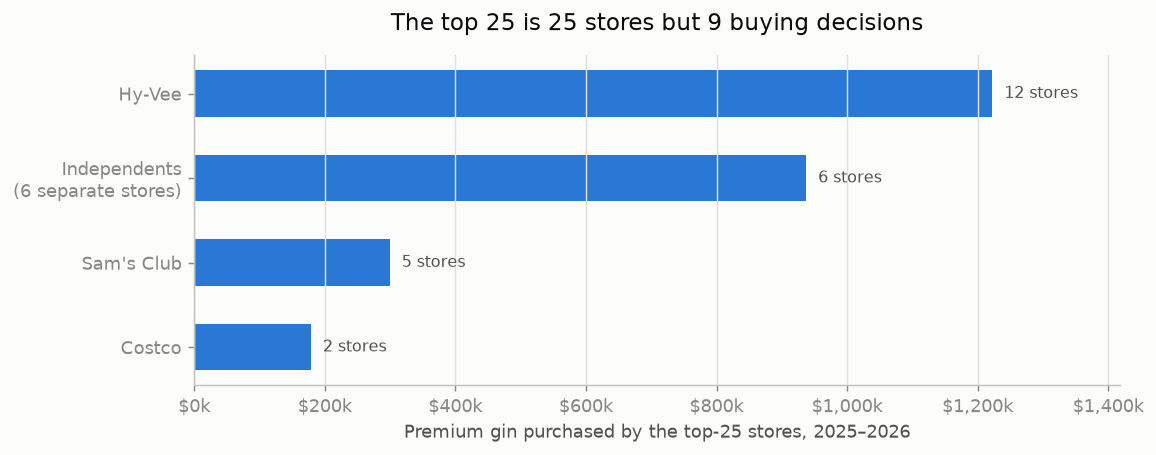

19 of the top 25 are chain locations; 6 are independents.
3 chain brands + 6 independents = 9 actual conversations


In [5]:
CHAIN_PATTERNS = {
    "Hy-Vee": r"HY-?VEE", "Costco": r"COSTCO", "Sam's Club": r"SAM.?S CLUB",
    "Walmart": r"WAL-?MART", "Target": r"TARGET", "Fareway": r"FAREWAY",
    "Casey's": r"CASEY", "Kwik Star": r"KWIK STAR", "Kum & Go / Maverik": r"KUM & GO|MAVERIK",
}

def parent_brand(name: str) -> str:
    upper = (name or "").upper()
    for brand, pattern in CHAIN_PATTERNS.items():
        if re.search(pattern, upper):
            return brand
    return "Independent"

top = targets[targets["is_top_target"]].copy()
top["parent"] = top["store_name"].map(parent_brand)

by_parent = (top.groupby("parent")
             .agg(stores=("store_number", "size"), premium_gin=("premium_gin_dollars", "sum"))
             .sort_values("premium_gin"))

# A chain brand is ONE conversation however many of its stores are listed; each
# independent is its own. That distinction is the whole point of this section.
n_indie = int(by_parent["stores"].get("Independent", 0))
n_brands = len([i for i in by_parent.index if i != "Independent"])
decisions = n_brands + n_indie
row_labels = [f"Independents\n({n_indie} separate stores)" if i == "Independent" else i
              for i in by_parent.index]

fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.barh(row_labels, by_parent["premium_gin"], color=BLUE, height=0.55)
ax.set_xlabel("Premium gin purchased by the top-25 stores, 2025–2026")
ax.set_title(f"The top 25 is 25 stores but {decisions} buying decisions", pad=14, fontsize=12.5)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}k"))
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)

for bar, (_, row) in zip(bars, by_parent.iterrows()):
    ax.text(bar.get_width() + by_parent["premium_gin"].max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{int(row.stores)} store{'s' if int(row.stores) > 1 else ''}",
            va="center", fontsize=9, color=INK2)
ax.set_xlim(0, by_parent["premium_gin"].max() * 1.16)

plt.tight_layout()
plt.show()

chains = int((top["parent"] != "Independent").sum())
print(f"{chains} of the top 25 are chain locations; {25 - chains} are independents.")
print(f"{n_brands} chain brands + {n_indie} independents = {decisions} actual conversations")

**Why this matters for a small London distiller.** A chain listing is a central category review,
often annual, usually via a distributor, and it is a different sale from walking into an
independent. It is not a reason to ignore the volume — Thameswood's own CRM already has
*Grocery Multiple* and *Wholesale Club* segments, so they do sell into chains — but the top 25
should be worked as **two lists, not one**.

## 5. The independents view

The same ranking with chain locations removed: stores where a rep can plausibly walk in and talk
to the person who chooses the gin. This is not a replacement for section 1 — it is the half of it
that is actionable next week.

In [6]:
indies = targets.copy()
indies["parent"] = indies["store_name"].map(parent_brand)
indies = indies[indies["parent"] == "Independent"].head(15)

display(pd.DataFrame({
    "Overall #": indies["target_rank"],
    "Store": indies["store_name"].str.title(),
    "City": indies["city"].str.title(),
    "Premium gin": indies["premium_gin_dollars"].map(usd),
    "prem %": (indies["premium_share_of_gin"] * 100).round(0).astype(int).astype(str) + "%",
    "In CRM?": indies["target_type"].map({"net_new": "no", "known_prospect": "yes"}),
}).set_index("Overall #"))

,Store,City,Premium gin,prem %,In CRM?
Overall #,,,,,
1,Central City 2,Des Moines,"$415,501",57%,no
4,Benz Distributing,Cedar Rapids,"$145,911",63%,no
5,Another Round / Dewitt,Dewitt,"$131,886",64%,no
6,Wall To Wall Wine And Spirits / West Des Moines,West Des Moines,"$126,828",59%,no
14,I-80 Liquor / Council Bluffs,Council Bluffs,"$65,789",76%,no
20,Wilkie Liquors,Mount Vernon,"$51,364",71%,no
27,Happy'S Wine & Spirits Wholesale,Cedar Falls,"$43,975",75%,no
31,Cyclone Liquors,Ames,"$41,572",60%,no
38,Madella Wine And Spirits / Bettendorf,Bettendorf,"$33,412",85%,yes


## 6. Market context — Thameswood is taking share in a shrinking category

Worth the client hearing plainly: the **imported** gin category Thameswood competes in has been declining for five years, and the
number of stores stocking it is falling faster than the dollars. Domestic gin, by contrast, is flat.

2026 is excluded from this chart — the data ends 30 April 2026, so it holds four months against
everyone else's twelve. Plotting it would show a cliff that is a calendar artefact, not a trend.

/Users/jeanchacon/Documents/codes/interviews/alchemia-labs-tech-assessment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


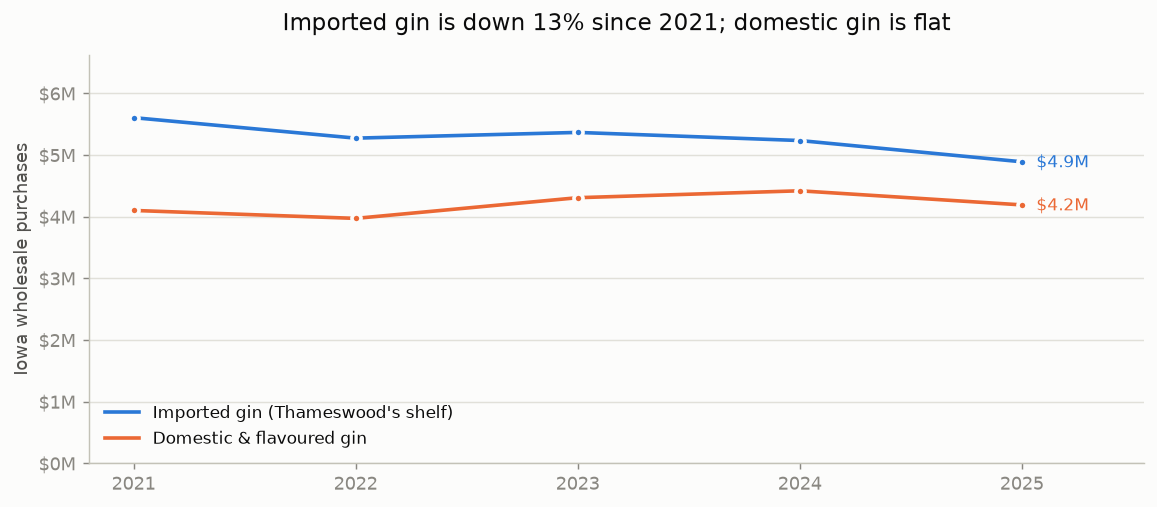

Imported gin dollars   2021 $5,605,621  ->  2025 $4,889,587   (-13%)
Stores stocking it     2021 1,416  ->  2025 1,088   (-23%)


In [7]:
trend = client.query(f'''
    select year, cat_group,
           sum(net_sale_dollars) as net_sale_dollars,
           count(distinct store_number) as stores
    from `{PROJECT}.analytics.stg_iowa__store_category_yearly`
    where cat_group != 'NON_GIN' and year between 2021 and 2025
    group by 1, 2 order by 1, 2
''').to_dataframe()

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(9, 4.0))
labels = {"GIN_PREMIUM": ("Imported gin (Thameswood's shelf)", BLUE),
          "GIN_OTHER": ("Domestic & flavoured gin", ORANGE)}

for group, (label, colour) in labels.items():
    s = trend[trend["cat_group"] == group]
    ax.plot(s["year"], s["net_sale_dollars"], color=colour, lw=2,
            marker="o", markersize=5, label=label,
            markeredgecolor=SURFACE, markeredgewidth=2)
    last = s.iloc[-1]
    ax.annotate(f"${last.net_sale_dollars/1e6:.1f}M", xy=(last.year, last.net_sale_dollars),
                xytext=(8, -3), textcoords="offset points", color=colour, fontsize=9.5)

ax.set_ylim(0, trend["net_sale_dollars"].max() * 1.18)
ax.set_xticks(range(2021, 2026))
ax.set_ylabel("Iowa wholesale purchases")
ax.set_title("Imported gin is down 13% since 2021; domestic gin is flat", pad=14, fontsize=12.5)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"${v/1e6:,.0f}M"))
ax.legend([Line2D([0], [0], color=c, lw=2) for c in (BLUE, ORANGE)],
          [labels["GIN_PREMIUM"][0], labels["GIN_OTHER"][0]],
          loc="lower left", fontsize=9.5)
ax.set_xlim(2020.8, 2025.55)

plt.tight_layout()
plt.show()

prem = trend[trend["cat_group"] == "GIN_PREMIUM"].set_index("year")
print(f"Imported gin dollars   2021 {usd(prem.net_sale_dollars.loc[2021])}  ->  2025 {usd(prem.net_sale_dollars.loc[2025])}"
      f"   ({(prem.net_sale_dollars.loc[2025]/prem.net_sale_dollars.loc[2021]-1)*100:+.0f}%)")
print(f"Stores stocking it     2021 {prem.stores.loc[2021]:,}  ->  2025 {prem.stores.loc[2025]:,}"
      f"   ({(prem.stores.loc[2025]/prem.stores.loc[2021]-1)*100:+.0f}%)")

Dollars are down ~13% since 2021; the number of stores stocking imported gin is down ~23%. Spend
per stocking store is therefore *rising* — the category is consolidating into fewer, more
committed outlets. That strengthens the case for this ranking: the stores at the top are not just
big, they are the ones still actively committed to the category.

## 7. Assumptions and caveats

**Scope decisions**

| Decision | Choice | Why |
|---|---|---|
| Universe | Iowa stores that bought imported gin in 2025–2026 | Market-side, not CRM-side — "grow the market" has to include stores the client has never heard of. |
| Window | Jan 2025 – Apr 2026 (16 months) | The same 16 months for every store, so it is fair to rank on. Not valid for year-on-year comparison. |
| Already won | Excluded | Already customers; there is nothing to approach. |
| Already lost | Excluded | Client has a bad history there and rep time is expensive. One flag (`exclude_closed_lost`) reverses it. |
| "Gin" | Iowa's `IMPORTED DRY GINS` + `IMPORTED GINS` | Matched to Thameswood's 41.4–47% ABV range. `AMERICAN SLOE GINS` excluded — a ~15–25% liqueur, not a competitor. |

**Known weaknesses of V1**

1. **Chain locations are ranked individually** (section 4). The single biggest gap.
2. **Five Closed Lost accounts cannot be excluded.** They have no `store_number` in the CRM, so
   they may reappear in the list as net-new. 3 of the 8 lost accounts *were* excludable.
3. **No momentum signal.** A store whose gin sales halved ranks the same as one that doubled.
   Fixing this needs the market extract re-run at month grain — calendar years cannot express a
   trailing twelve months.
4. **Fit is computed but not used.** `premium_share_of_gin` is in the table and shown above, but
   V1 ranks on dollars alone, so a mid-size store that is 86% premium loses to a giant that is 44%.
5. **Recency is ignored.** A store that last bought gin in early 2025 ranks alongside one buying
   monthly.
6. **Store attributes come from the market data**, which is a wholesale feed — a few top entries
   look like distribution depots rather than retail storefronts and are worth eyeballing.

**What I would ask the client**

- Are chain accounts (Hy-Vee, Costco, Sam's Club) actually approachable, or handled by a
  distributor? This changes the deliverable more than any modelling choice.
- Should Closed Lost accounts be permanently excluded, or revisited after some period?
- Is there a minimum viable order size below which an account is not worth opening?

## 8. What V2 adds

In priority order, each justified by something visible above:

1. **Group chain locations to a parent brand** — turns 25 stores into ~7 decisions. Biggest
   actionability win, needs no new data. *(section 4)*
2. **Add fit as a scored component** — `premium_share_of_gin` already exists; surfaces the
   specialist that is 86% premium over the giant that is 44%. *(section 1)*
3. **Rank on percentiles rather than raw dollars** — the 6.6× mean/median gap is exactly why one
   raw measure lets store size dominate. *(section 2)*
4. **Re-extract the market data at month grain** — unlocks trailing-twelve-month windows and a
   like-for-like momentum signal. ~4 GB of the 1 TB monthly budget. *(section 6)*

Weights for any composite score will live in `dbt_project.yml` as `vars`, not in SQL, so the
client can retune them without a code change — and every component score will be published
alongside the rank so a rep can see *why* a store is where it is.